In [1]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from data_utils import fillna_data
from analysis_utils import model_analysis, model_visualization, discipline_analysis
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transform_utils import LightGBM_model
from sklearn.metrics import mean_absolute_error, f1_score

In [2]:
FEATURES = ['program', 'education_level', 'place_type', 'course', 'absence_status', 'discipline', 'module',
       'exam_type', 'grade_10', 'difficulty_avg_score', 'exam_type_prev', 'grade_prev', 'difficulty_prev',
       'avg_grade_prev', 'min_prev', 'max_prev']

In [3]:
CATBOOST_HYPERPARAMETRS = {'iterations': 494, 'learning_rate': 0.3788119430934142, 'loss_function': 'MAE', 'depth': 2, 'l2_leaf_reg': 38.39899891347804, 'min_data_in_leaf': 57}
LIGHTGBM_HYPERPARAMETRS = {'learning_rate': 0.05593308405682298, 'num_leaves': 49, 'max_depth': 5, 'n_estimators': 523, 'bagging_fraction': 0.7553386111732491, 'min_child_samples': 177, 'feature_fraction': 0.5700191961275134}

In [4]:
class Trajectory: 
    def __init__(self):
        self.grade_model = CatBoostRegressor(**CATBOOST_HYPERPARAMETRS, verbose=False)
        self.type_model = LightGBM_model(**LIGHTGBM_HYPERPARAMETRS)

        self.features = FEATURES
        self.cat_features = None


    def _fillna_data(self, data):
        return fillna_data(data)
    
    def fit(self, data):
        data_filled = self._fillna_data(data)
        X = data_filled[self.features]
        y_grade = data_filled['target_grade']
        
        self.cat_features = [col for col in self.features if X[col].dtype in ('str', 'object')]
        X_pool = Pool(X, y_grade, self.cat_features)
        self.grade_model.fit(X_pool)

        self.type_model.fit(data_filled)

    def predict(self, data, visualization=False):
        data = self._fillna_data(data)
        X = data[self.features]
        grades_pred = self.grade_model.predict(X)
        grades_pred = np.clip(np.round(grades_pred), a_min = 0, a_max = 10) # оценка от 0 до 10

        type_pred = self.type_model.predict_type(data)
        
        if visualization == True:
            self.visualize(grades_pred, type_pred)

        return grades_pred, type_pred 

    def analysis(self, y_true_grade, y_pred_grade, y_true_type, y_pred_type):
        model_analysis(y_true_grade, y_pred_grade, y_true_type, y_pred_type)


    def visualize(self, grades_pred, type_pred):
        model_visualization(grades_pred, type_pred)

    def discipline_check(self, data, discipline_name):
        discipline_analysis(data, discipline_name)

    def save(self, path):
        joblib.dump(self, path)

    @staticmethod
    def load(path):
        return joblib.load(path)
    

Проверяем модель:

In [5]:
data = pd.read_csv('total_laggs.csv', low_memory=False)

In [6]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=0)
test_data1, test_data2 = train_test_split(test_data, test_size=0.5, random_state=0, shuffle=True)

Обучаем модель: 

In [7]:
model = Trajectory()
model.fit(train_data)

In [8]:
model.discipline_check(test_data1, 'Алгоритмы и структуры данных')

Средняя сложность: 4.1579
Средняя оценка: 5.516129032258065
Медианная оценка: 6.0


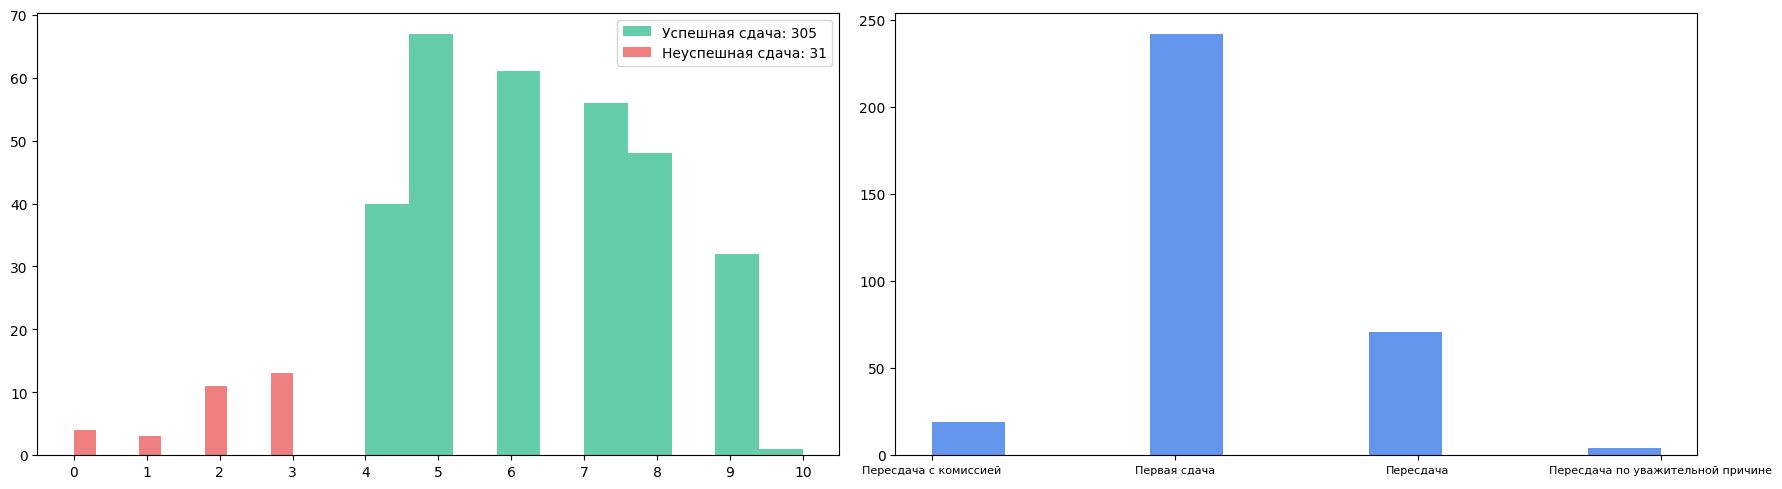

In [9]:
y_pred, y_pred1 = model.predict(test_data1, visualization=True)

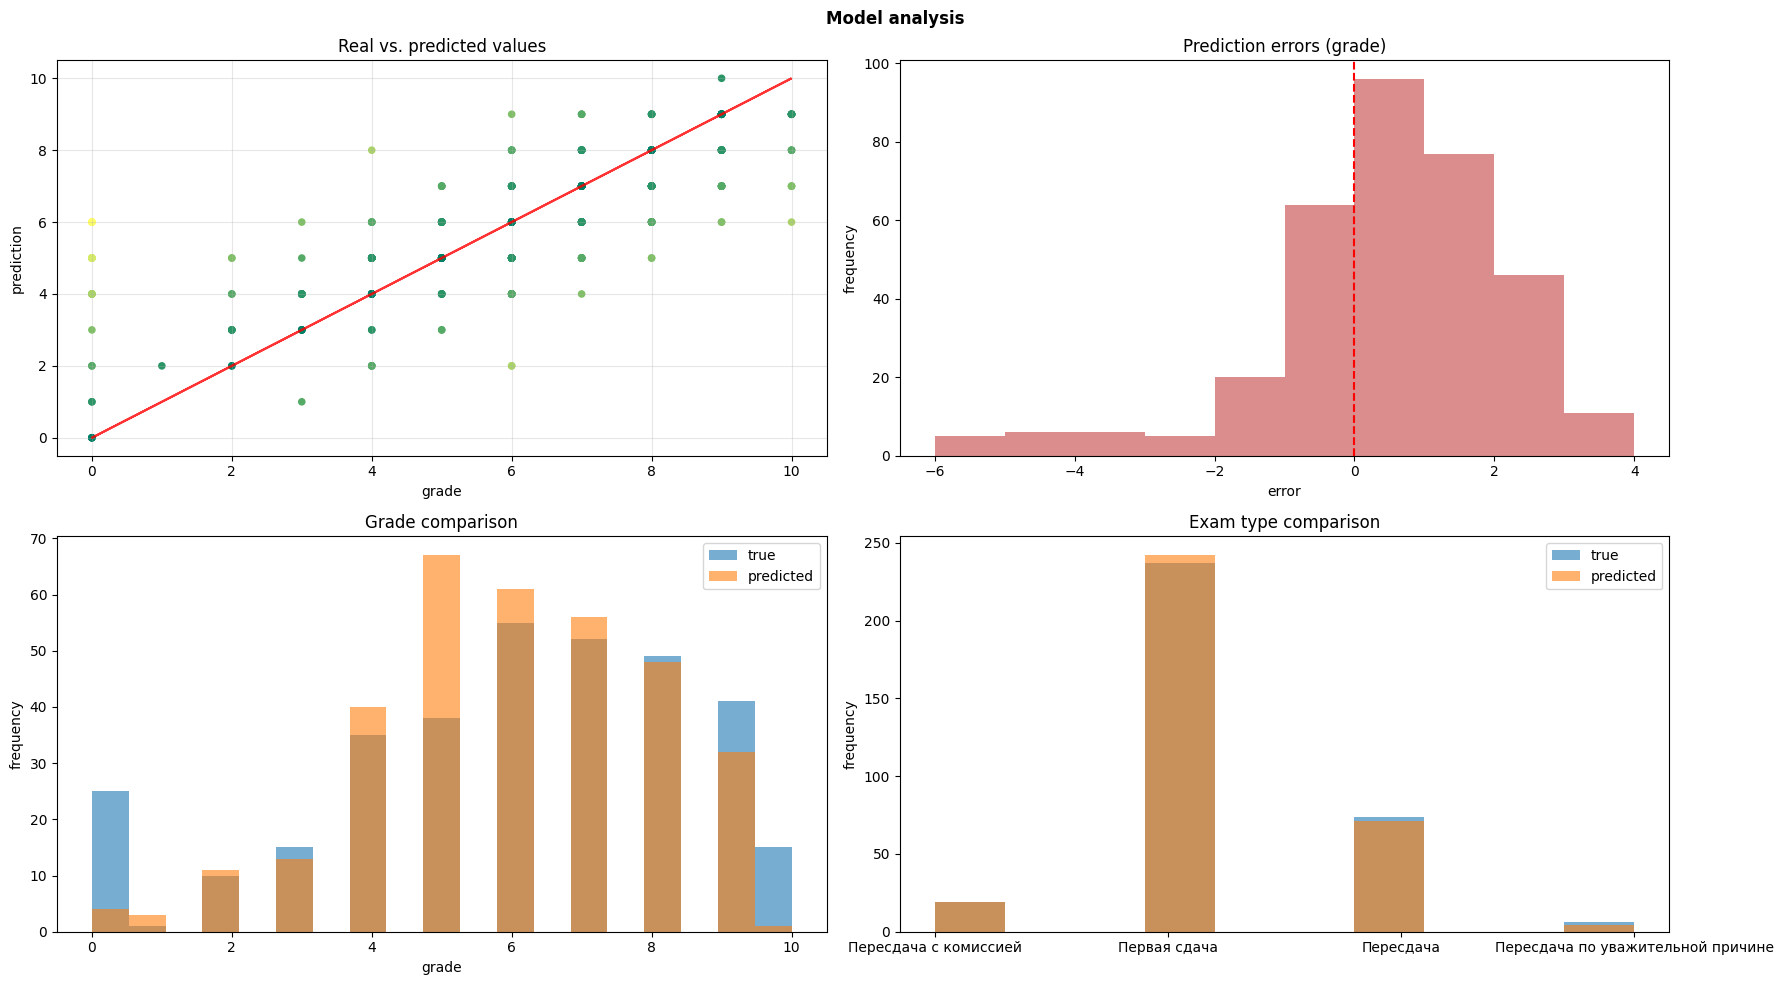

In [10]:
model.analysis(test_data1['target_grade'], y_pred, test_data1['target_type'], y_pred1)

In [11]:
mean_absolute_error(y_pred, test_data1['target_grade'])

1.2142857142857142

In [12]:
f1_score(y_pred1, test_data1['target_type'], average='weighted')

0.959220084261478

In [13]:
model.save("trajectory_model.pkl")